<a href="https://colab.research.google.com/github/roboy88/IUL-vs-Market-NVDA-stock-simulation-/blob/main/IUL_vs_Market_NVDA_stock_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Stocks_Data_10yrs.xlsx to Stocks_Data_10yrs (1).xlsx


<ipython-input-2-d66c68bce6c8>:16: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_close = nvda_df['Close'].resample('Y').last()


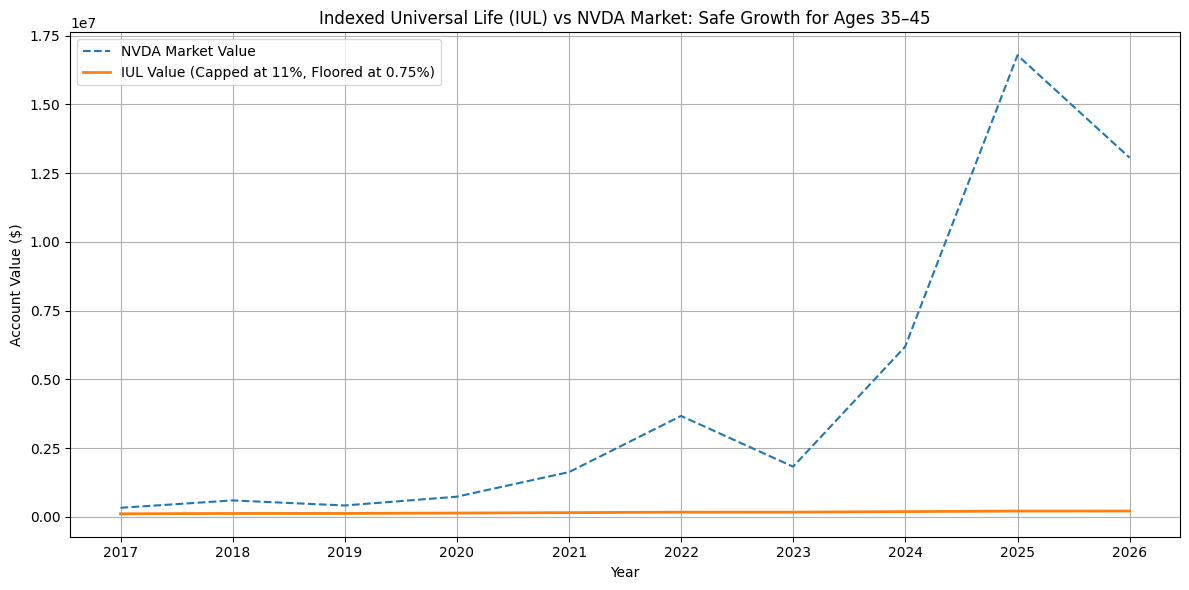

Annual Comparison:
2016 | Market Return: 228.75% | IUL Credit: 11.00%
2017 | Market Return: 81.75% | IUL Credit: 11.00%
2018 | Market Return: -30.75% | IUL Credit: 0.75%
2019 | Market Return: 77.04% | IUL Credit: 11.00%
2020 | Market Return: 122.18% | IUL Credit: 11.00%
2021 | Market Return: 125.50% | IUL Credit: 11.00%
2022 | Market Return: -50.27% | IUL Credit: 0.75%
2023 | Market Return: 239.04% | IUL Credit: 11.00%
2024 | Market Return: 171.27% | IUL Credit: 11.00%
2025 | Market Return: -22.18% | IUL Credit: 0.75%


In [2]:
# STEP 1: INSTALL & IMPORT
import pandas as pd
import matplotlib.pyplot as plt

# STEP 2: UPLOAD FILE
from google.colab import files
uploaded = files.upload()

# STEP 3: LOAD AND PREPARE DATA
df = pd.read_excel('Stocks_Data_10yrs.xlsx', sheet_name='Companies_Stocks')
df['Date'] = pd.to_datetime(df['Date'])

# STEP 4: FILTER FOR NVDA AND ANNUAL RETURNS
nvda_df = df[df['Ticker'] == 'NVDA'].copy()
nvda_df.set_index('Date', inplace=True)
annual_close = nvda_df['Close'].resample('Y').last()
annual_return = annual_close.pct_change().dropna().reset_index()
annual_return.columns = ['Date', 'Annual_Return']

# STEP 5: APPLY IUL CREDITING RULES
annual_return['IUL_Credit'] = annual_return['Annual_Return'].clip(lower=0.0075, upper=0.11)

# STEP 6: SIMULATE ACCOUNT GROWTH
initial_value = 100000  # Starting with $100k
annual_return['Market_Value'] = initial_value * (1 + annual_return['Annual_Return']).cumprod()
annual_return['IUL_Value'] = initial_value * (1 + annual_return['IUL_Credit']).cumprod()

# STEP 7: PLOT RESULTS
plt.figure(figsize=(12, 6))
plt.plot(annual_return['Date'], annual_return['Market_Value'], label='NVDA Market Value', linestyle='--')
plt.plot(annual_return['Date'], annual_return['IUL_Value'], label='IUL Value (Capped at 11%, Floored at 0.75%)', linewidth=2)
plt.title('Indexed Universal Life (IUL) vs NVDA Market: Safe Growth for Ages 35–45')
plt.xlabel('Year')
plt.ylabel('Account Value ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 8: PRINT RETURNS FOR DISCUSSION
print("Annual Comparison:")
for i, row in annual_return.iterrows():
    print(f"{row['Date'].year} | Market Return: {row['Annual_Return']:.2%} | IUL Credit: {row['IUL_Credit']:.2%}")
